In [91]:
# -------------------------
#     ECE 18 PROJECT
#     AWIN APOLLO PEREZ
#     SP26
# ------------------------

In [92]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.decomposition import PCA

from sklearn.inspection import permutation_importance

In [93]:
# upload data from my Google Drive
from google.colab import drive
drive.mount('/content/drive')
dataset = pd.read_csv('/content/drive/MyDrive/ev_battery_charging_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
# encode categorial columns so models can use them
# convert text labels into numbers
le = LabelEncoder()
for col in ['Charging Mode', 'Battery Type', 'EV Model']:
  dataset[col] = le.fit_transform(dataset[col])

In [95]:
# debug to see fi no text remains
print(dataset.dtypes)

SOC (%)                            float64
Voltage (V)                        float64
Current (A)                        float64
Battery Temp (°C)                  float64
Ambient Temp (°C)                  float64
Charging Duration (min)            float64
Degradation Rate (%)               float64
Charging Mode                        int64
Efficiency (%)                     float64
Battery Type                         int64
Charging Cycles                      int64
EV Model                             int64
Optimal Charging Duration Class      int64
dtype: object


In [96]:
# Extract features and labels
# target column is 3 classes (0, 1, 2)
# three columns are text/categorical
X = dataset.drop(columns=['Optimal Charging Duration Class'])
y = dataset['Optimal Charging Duration Class']

#features_names = dataset.feature_names
#target_names = dataset.target_names

In [97]:
# split into train, validation, and test sets
# CHANGE THIS LATER IF NECESSARY
# 80 20 train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#print(f"Training samples: {len(X_train)}, Validation samples: {len(X_valid)}, Test samples: {len(X_test)}\n")

In [98]:
# scale features for kNN
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [99]:
# Logistic Regression
lr = LogisticRegression(max_iter=10000) # might change this to 1000
lr.fit(X_train, y_train)
print("Logistic Regression accuracy:", accuracy_score(y_test, lr.predict(X_test)))

# kNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("kNN accuracy", accuracy_score(y_test, knn.predict(X_test)))

# mlp
mlp = MLPClassifier(hidden_layer_sizes=(64,32),
                    activation='relu',
                    max_iter=10000,
                    random_state=42
)

mlp.fit(X_train, y_train)
print("MLP accuracy:", accuracy_score(y_test, mlp.predict(X_test)))

Logistic Regression accuracy: 1.0
kNN accuracy 0.85
MLP accuracy: 0.935


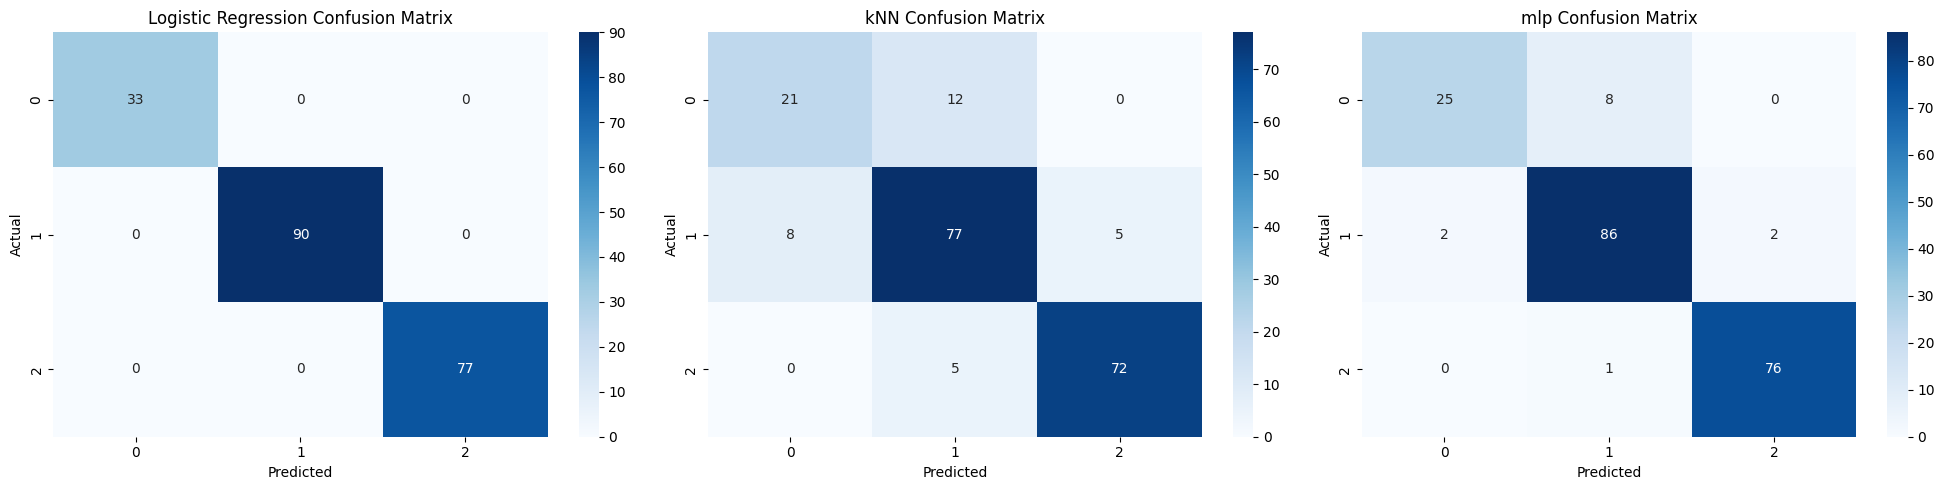

In [100]:
# plotting!

# confusion matrices
fig, axes = plt.subplots(1,3,figsize=(20,5))

for ax, model, name in zip(axes, [lr, knn, mlp], ['Logistic Regression', 'kNN', 'mlp']):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

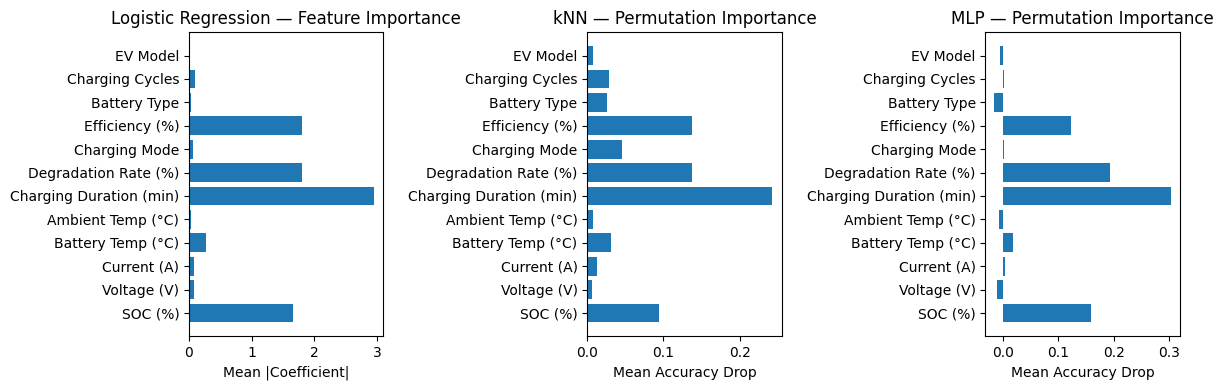

In [101]:
# feature importance

feature_names = dataset.drop(columns=['Optimal Charging Duration Class']).columns

fig, axes = plt.subplots(1,3,figsize=(12,4))

# Logistic Regression — unchanged
lr_importance = np.mean(np.abs(lr.coef_), axis=0)
axes[0].barh(feature_names, lr_importance)
axes[0].set_title('Logistic Regression — Feature Importance')
axes[0].set_xlabel('Mean |Coefficient|')

# kNN — unchanged
perm_knn = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)
axes[1].barh(feature_names, perm_knn.importances_mean)
axes[1].set_title('kNN — Permutation Importance')
axes[1].set_xlabel('Mean Accuracy Drop')

# MLP — also uses permutation importance (no built-in coefficients)
perm_mlp = permutation_importance(mlp, X_test, y_test, n_repeats=10, random_state=42)
axes[2].barh(feature_names, perm_mlp.importances_mean)
axes[2].set_title('MLP — Permutation Importance')
axes[2].set_xlabel('Mean Accuracy Drop')

plt.tight_layout()
plt.show()

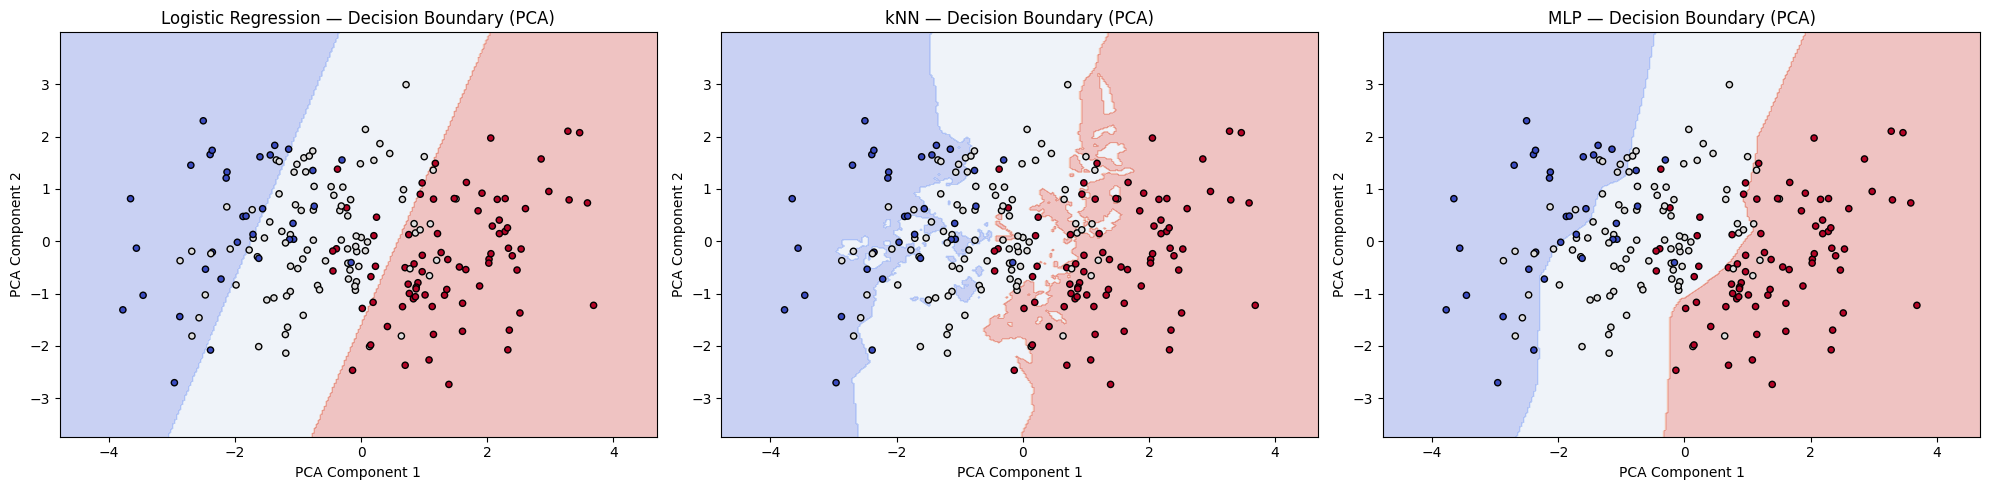

In [102]:
#putting decision boundaries

fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # ← change 2 to 3

for ax, Model, name in zip(axes,
                            [LogisticRegression(max_iter=1000),
                             KNeighborsClassifier(n_neighbors=5),
                             MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)],  # ← add MLP
                            ['Logistic Regression', 'kNN', 'MLP']):
    Model.fit(X_train_2d, y_train)
    x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
    y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = Model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', s=20)
    ax.set_title(f'{name} — Decision Boundary (PCA)')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

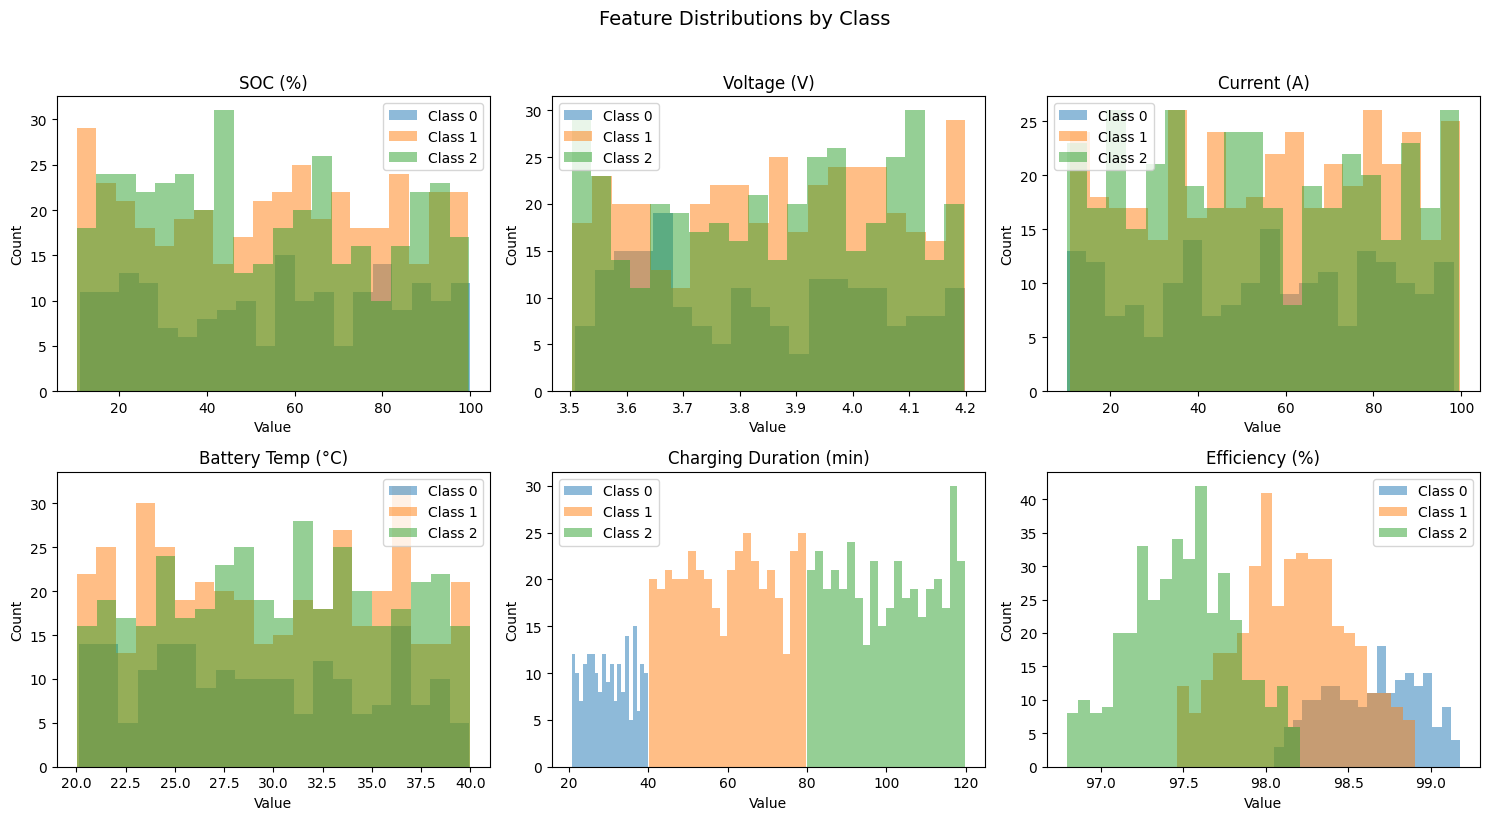

In [104]:
# data distribution

numeric_cols = ['SOC (%)', 'Voltage (V)', 'Current (A)',
                'Battery Temp (°C)', 'Charging Duration (min)', 'Efficiency (%)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    for cls in sorted(dataset['Optimal Charging Duration Class'].unique()):
        subset = dataset[dataset['Optimal Charging Duration Class'] == cls][col]
        ax.hist(subset, bins=20, alpha=0.5, label=f'Class {cls}')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Feature Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()